# CASALS L1B Refh Forward Reconstruction Validation

This notebook strictly tests whether the official H5 `refh` coordinate can be reconstructed from the H5 instrument position, beam angles, range-window geometry, `bin_size`, and the RX waveform peak bin.

The validation is intentionally direct:

1. Select one sweep from a CASALS L1B H5 file.
2. Load per-pulse instrument coordinates: `instrument_longitude`, `instrument_latitude`, `instrument_altitude`.
3. Load per-pulse beam angles: `local_beam_azimuth`, `local_beam_elevation`.
4. Load official refh coordinates: `refh_longitude`, `refh_latitude`, `refh`.
5. Load range-window geometry: `rwstart_longitude/latitude/rwstart`, `rwstop_longitude/latitude/rwstop`, `bin_size`.
6. Load the selected sweep's `rx_waveform` and detect the raw peak bin.
7. Reconstruct the peak/refh 3D coordinate by forward beam/range propagation.
8. Compare the reconstructed coordinate with the H5 `refh` coordinate.

The CryoCloud CASALS L1B tutorial states that `refh` is the geolocated reference height of the waveform bin with maximum amplitude, and it lists the necessary L1B variables, including `instrument_altitude`, beam angles, `rwstart/rwstop`, `bin_size`, and `rx_waveform`.

**Boundary.** If the forward reconstruction does not exactly match H5 `refh`, it does not immediately invalidate the beam-angle convention. The discrepancy may come from bin-center/bin-edge convention, sub-bin peak localization, processed versus raw peak definition, range-bias correction, bounce-time offsets, or other L1B geophysical corrections.

## 1. Geometry model

For pulse / track $i$, define the H5 instrument position and official refh point in projected East-North-Up coordinates:

$$
\mathbf{I}_i=(X_i,Y_i,Z_i),\qquad \mathbf{P}_{i,ref}=(x_i,y_i,z_i).
$$

Using the current canonical CASALS beam convention:

$$
\mathbf{u}_i =
-
\begin{bmatrix}
\cos(e_i)\sin(a_i)\\
\cos(e_i)\cos(a_i)\\
\sin(e_i)
\end{bmatrix},
$$

where $a_i$ is north-clockwise azimuth and $e_i$ is elevation from horizon.

Let $\mathbf{R}^{start}_i$ and $\mathbf{R}^{stop}_i$ be H5 `rwstart` and `rwstop` points. Their signed ranges along the beam are:

$$
r_{start,i}=(\mathbf{R}^{start}_i-\mathbf{I}_i)\cdot\mathbf{u}_i,
$$

$$
r_{stop,i}=(\mathbf{R}^{stop}_i-\mathbf{I}_i)\cdot\mathbf{u}_i.
$$

For raw RX peak bin $b_{peak,i}$, one candidate peak range is:

$$
r_{peak,i}=r_{start,i}+(b_{peak,i}+\alpha)\Delta r_i,
$$

where $\Delta r_i=\text{bin\_size}_i$, and $\alpha$ represents the bin-center/bin-edge convention.

The reconstructed refh coordinate is:

$$
\hat{\mathbf{P}}_{i,ref}=\mathbf{I}_i+r_{peak,i}\mathbf{u}_i.
$$

The strict validation residual is:

$$
\mathbf{e}_i=\hat{\mathbf{P}}_{i,ref}-\mathbf{P}_{i,ref}.
$$

## 2. Configuration

In [4]:
from __future__ import annotations

import json
import math
from pathlib import Path
from typing import Any, Dict, Optional, Sequence, Tuple, List

import h5py
import numpy as np
import pandas as pd
from pyproj import CRS, Transformer

import matplotlib.pyplot as plt
import plotly.graph_objects as go

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 160)

H5_CANDIDATES = [
    Path('../casals_h5_downloads/casals_l1b_20241112T165718_001_02.h5'),
    Path('./casals_h5_downloads/casals_l1b_20241112T165718_001_02.h5'),
    Path('casals_h5_downloads/casals_l1b_20241112T165718_001_02.h5'),
]
SWEEP_INDEX = 7040

# Main interpretation: no-bias canonical beam convention.
AZ_BIAS_DEG_MAIN = 0.0
EL_BIAS_DEG_MAIN = 0.0

# Optional calibration sensitivity test.
RUN_REFINED_AZ_BIAS_TEST = True
AZ_BIAS_DEG_REFINED = 0.10

# Candidate bin-center/bin-edge offsets.
ALPHA_CANDIDATES = [0.0, 0.5, -0.5]

# Candidate peak-bin integer offsets. Keep 0 for strict raw-argmax; neighbor offsets help detect systematic bin shifts.
PEAK_BIN_OFFSETS = [0, -2, -1, 1, 2]

# If true, subtract bg_mean before argmax. This should not change argmax because bg_mean is per-pulse scalar.
SUBTRACT_BG_MEAN_FOR_PEAK = False

TRACK_TO_VIEW = 128
MAX_RESIDUAL_LINES_3D = 256

def first_existing_path(paths):
    for p in paths:
        if p.exists():
            return p
    return paths[0]

H5_PATH = first_existing_path(H5_CANDIDATES)
print('H5_PATH:', H5_PATH)
print('H5 exists:', H5_PATH.exists())
print('SWEEP_INDEX:', SWEEP_INDEX)

H5_PATH: ..\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5
H5 exists: True
SWEEP_INDEX: 7040


## 3. H5 field discovery

In [5]:
DATASET_CANDIDATES: Dict[str, Sequence[str]] = {
    'sweep_num': ('sweep_num', 'sweep', 'sweep_index'),
    'track_num': ('track_num', 'track', 'track_index'),
    'delta_time': ('delta_time', 'time'),
    'refh_lon': ('refh_longitude', 'longitude', 'lon'),
    'refh_lat': ('refh_latitude', 'latitude', 'lat'),
    'refh_z': ('refh', 'refh_height', 'height', 'elevation'),
    'refh_amp': ('refh_amp',),
    'refh_snr': ('refh_snr',),
    'refh_error': ('refh_error',),
    'instrument_lon': ('instrument_longitude', 'sensor_longitude', 'platform_longitude'),
    'instrument_lat': ('instrument_latitude', 'sensor_latitude', 'platform_latitude'),
    'instrument_z': ('instrument_altitude', 'instrument_height', 'sensor_altitude', 'platform_altitude'),
    'instrument_z_error': ('instrument_altitude_error',),
    'beam_az': ('local_beam_azimuth', 'beam_azimuth', 'azimuth'),
    'beam_el': ('local_beam_elevation', 'beam_elevation', 'elevation'),
    'beam_az_error': ('local_beam_azimuth_error',),
    'beam_el_error': ('local_beam_elevation_error',),
    'rwstart_lon': ('rwstart_longitude',),
    'rwstart_lat': ('rwstart_latitude',),
    'rwstart_z': ('rwstart',),
    'rwstop_lon': ('rwstop_longitude',),
    'rwstop_lat': ('rwstop_latitude',),
    'rwstop_z': ('rwstop',),
    'bin_size': ('bin_size',),
    'bg_mean': ('bg_mean',),
    'bg_std': ('bg_std',),
    'range_bias_correction': ('range_bias_correction',),
    'rx_waveform': ('rx_waveform',),
    'rx_bins': ('rx_bins',),
}

REQUIRED_FIELDS = [
    'sweep_num', 'track_num',
    'refh_lon', 'refh_lat', 'refh_z',
    'instrument_lon', 'instrument_lat', 'instrument_z',
    'beam_az', 'beam_el',
    'rwstart_lon', 'rwstart_lat', 'rwstart_z',
    'rwstop_lon', 'rwstop_lat', 'rwstop_z',
    'bin_size', 'rx_waveform',
]

def build_basename_index(h5: h5py.File) -> Dict[str, str]:
    out = {}
    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            out[name.split('/')[-1]] = name
    h5.visititems(visitor)
    return out

def find_dataset_path(h5: h5py.File, candidates: Sequence[str], required: bool = False) -> Optional[str]:
    for name in candidates:
        if name in h5 and isinstance(h5[name], h5py.Dataset):
            return name
    basename_to_path = build_basename_index(h5)
    for name in candidates:
        if name in basename_to_path:
            return basename_to_path[name]
    if required:
        raise KeyError(f'Could not find any dataset from candidates: {list(candidates)}')
    return None

def inspect_field_map(h5_path: Path) -> pd.DataFrame:
    rows = []
    with h5py.File(h5_path, 'r') as h5:
        for logical, candidates in DATASET_CANDIDATES.items():
            path = find_dataset_path(h5, candidates, required=False)
            if path is None:
                rows.append({
                    'logical_name': logical, 'dataset_path': None, 'exists': False,
                    'shape': None, 'dtype': None, 'required_for_validation': logical in REQUIRED_FIELDS,
                })
            else:
                ds = h5[path]
                rows.append({
                    'logical_name': logical, 'dataset_path': path, 'exists': True,
                    'shape': tuple(ds.shape), 'dtype': str(ds.dtype),
                    'required_for_validation': logical in REQUIRED_FIELDS,
                })
    return pd.DataFrame(rows)

if H5_PATH.exists():
    field_map_df = inspect_field_map(H5_PATH)
    display(field_map_df)
    missing_required = field_map_df.loc[field_map_df['required_for_validation'] & ~field_map_df['exists'], 'logical_name'].tolist()
    if missing_required:
        raise RuntimeError(f'Missing required validation fields: {missing_required}')
else:
    field_map_df = pd.DataFrame()
    print('H5 file not found. Update H5_CANDIDATES / H5_PATH before running.')

,logical_name,dataset_path,exists,shape,dtype,required_for_validation
0,sweep_num,sweep_num,True,"(3604480,)",int64,True
1,track_num,track_num,True,"(3604480,)",int64,True
2,delta_time,delta_time,True,"(3604480,)",float64,False
3,refh_lon,refh_longitude,True,"(3604480,)",float64,True
4,refh_lat,refh_latitude,True,"(3604480,)",float64,True
5,refh_z,refh,True,"(3604480,)",float64,True
6,refh_amp,refh_amp,True,"(3604480,)",int16,False
7,refh_snr,refh_snr,True,"(3604480,)",float64,False
8,refh_error,refh_error,True,"(3604480,)",float32,False
9,instrument_lon,instrument_longitude,True,"(3604480,)",float64,True


## 4. Load one sweep and its RX waveforms

In [6]:
def read_1d_dataset(h5: h5py.File, logical_name: str, required: bool = True) -> Tuple[Optional[np.ndarray], Optional[str]]:
    path = find_dataset_path(h5, DATASET_CANDIDATES[logical_name], required=required)
    if path is None:
        return None, None
    return np.asarray(h5[path][...]).reshape(-1), path

def read_selected_1d(h5: h5py.File, logical_name: str, indices: np.ndarray, required: bool = True) -> Tuple[Optional[np.ndarray], Optional[str]]:
    arr, path = read_1d_dataset(h5, logical_name, required=required)
    if arr is None:
        return None, path
    if arr.shape[0] <= int(np.max(indices)):
        raise ValueError(f'Dataset {path} has length {arr.shape[0]}, but max selected index is {int(np.max(indices))}.')
    return np.asarray(arr[indices]), path

def load_sweep_and_waveforms(h5_path: Path, sweep_index: int) -> Tuple[pd.DataFrame, np.ndarray, Dict[str, Optional[str]]]:
    with h5py.File(h5_path, 'r') as h5:
        sweep_num, sweep_path = read_1d_dataset(h5, 'sweep_num', required=True)
        track_num_all, track_path = read_1d_dataset(h5, 'track_num', required=True)

        record_indices = np.flatnonzero(np.asarray(sweep_num) == sweep_index)
        if record_indices.size == 0:
            raise RuntimeError(f'No records found for sweep_index={sweep_index}')

        track_sel = np.asarray(track_num_all[record_indices], dtype=np.int64)
        order = np.argsort(track_sel, kind='mergesort')
        record_indices = record_indices[order]
        track_sel = track_sel[order]

        unique_tracks, first_pos = np.unique(track_sel, return_index=True)
        duplicate_count = int(track_sel.size - unique_tracks.size)
        if duplicate_count > 0:
            keep = np.sort(first_pos)
            record_indices = record_indices[keep]
            track_sel = track_sel[keep]

        table = pd.DataFrame({
            'record_index': record_indices.astype(np.int64),
            'track_num': track_sel.astype(np.int64),
            'sweep_num': int(sweep_index),
        })

        source_paths = {'sweep_num': sweep_path, 'track_num': track_path, 'duplicate_records_removed_for_same_track': str(duplicate_count)}

        one_d_fields = [
            'delta_time',
            'refh_lon', 'refh_lat', 'refh_z', 'refh_amp', 'refh_snr', 'refh_error',
            'instrument_lon', 'instrument_lat', 'instrument_z', 'instrument_z_error',
            'beam_az', 'beam_el', 'beam_az_error', 'beam_el_error',
            'rwstart_lon', 'rwstart_lat', 'rwstart_z',
            'rwstop_lon', 'rwstop_lat', 'rwstop_z',
            'bin_size', 'bg_mean', 'bg_std', 'range_bias_correction',
        ]
        for logical_name in one_d_fields:
            arr, path = read_selected_1d(h5, logical_name, record_indices, required=False)
            source_paths[logical_name] = path
            if arr is not None:
                table[logical_name] = arr

        rx_path = find_dataset_path(h5, DATASET_CANDIDATES['rx_waveform'], required=True)
        source_paths['rx_waveform'] = rx_path
        h5_read_order = np.argsort(record_indices, kind='mergesort')
        record_indices_h5 = record_indices[h5_read_order]
        restore_order = np.argsort(h5_read_order, kind='mergesort')
        rx_waveforms = np.asarray(h5[rx_path][record_indices_h5, :])[restore_order, :]

        rx_bins_path = find_dataset_path(h5, DATASET_CANDIDATES['rx_bins'], required=False)
        source_paths['rx_bins'] = rx_bins_path
        if rx_bins_path is not None:
            rx_bins = np.asarray(h5[rx_bins_path][...])
            if rx_bins.ndim == 1:
                source_paths['rx_bins_minmax'] = f'{int(np.nanmin(rx_bins))}:{int(np.nanmax(rx_bins))}'

    return table, rx_waveforms, source_paths

if H5_PATH.exists():
    sweep_df, rx_waveforms, source_paths = load_sweep_and_waveforms(H5_PATH, SWEEP_INDEX)
    print('Sweep records:', len(sweep_df))
    print('Unique tracks:', sweep_df['track_num'].nunique())
    print('Track range:', int(sweep_df['track_num'].min()), 'to', int(sweep_df['track_num'].max()))
    print('rx_waveforms shape:', rx_waveforms.shape)
    display(sweep_df.head())
    display(pd.DataFrame([{'logical_name': k, 'dataset_path_or_info': v} for k, v in source_paths.items()]))
else:
    sweep_df = pd.DataFrame()
    rx_waveforms = np.empty((0, 0))
    source_paths = {}

Sweep records: 256
Unique tracks: 256
Track range: 0 to 255
rx_waveforms shape: (256, 2728)


,record_index,track_num,sweep_num,delta_time,refh_lon,refh_lat,refh_z,refh_amp,refh_snr,refh_error,instrument_lon,instrument_lat,instrument_z,instrument_z_error,beam_az,beam_el,beam_az_error,beam_el_error,rwstart_lon,rwstart_lat,rwstart_z,rwstop_lon,rwstop_lat,rwstop_z,bin_size,bg_mean,bg_std,range_bias_correction
0,1802240,0,7040,2.166659e+08,-75.285002,38.414235,85.320913,474,1.600913,0.039534,-75.285879,38.410807,8590.903123,0.020303,-2.942861,1.525133,0.001914,0.000087,-75.285015,38.414183,213.987269,-75.284973,38.414348,-194.390278,0.149699,-37.274351,111.118469,0.0
1,1802272,1,7040,2.166659e+08,-75.284985,38.414281,-26.057590,684,2.419499,0.039927,-75.285879,38.410807,8590.903094,0.020303,-2.941764,1.525116,0.001914,0.000087,-75.285010,38.414184,213.984330,-75.284967,38.414349,-194.392892,0.149698,-16.677265,99.793460,0.0
2,1802304,2,7040,2.166659e+08,-75.285000,38.414211,150.148342,539,1.954163,0.039342,-75.285879,38.410807,8590.903065,0.020303,-2.941037,1.525086,0.001912,0.000087,-75.285006,38.414186,213.994917,-75.284964,38.414350,-194.381754,0.149698,-14.133188,96.651514,0.0
3,1802336,3,7040,2.166659e+08,-75.284973,38.414297,-57.475681,414,1.790321,0.040073,-75.285879,38.410808,8590.903035,0.020303,-2.940064,1.525059,0.001911,0.000087,-75.285001,38.414187,214.002153,-75.284959,38.414352,-194.374006,0.149698,-30.732514,87.325307,0.0
4,1802368,4,7040,2.166659e+08,-75.284988,38.414226,121.120384,566,2.259791,0.039469,-75.285879,38.410808,8590.903006,0.020303,-2.939343,1.525042,0.001911,0.000087,-75.284998,38.414188,214.008318,-75.284955,38.414353,-194.367527,0.149698,-18.557771,89.674485,0.0


,logical_name,dataset_path_or_info
0,sweep_num,sweep_num
1,track_num,track_num
2,duplicate_records_removed_for_same_track,0
3,delta_time,delta_time
4,refh_lon,refh_longitude
5,refh_lat,refh_latitude
6,refh_z,refh
7,refh_amp,refh_amp
8,refh_snr,refh_snr
9,refh_error,refh_error


## 5. Project coordinates and compute canonical beam vectors

In [7]:
def infer_wgs84_utm_epsg(lon: np.ndarray, lat: np.ndarray) -> int:
    lon_med = float(np.nanmedian(lon))
    lat_med = float(np.nanmedian(lat))
    zone = int(math.floor((lon_med + 180.0) / 6.0) + 1)
    zone = max(1, min(zone, 60))
    return (32600 if lat_med >= 0.0 else 32700) + zone

def project_lonlat_to_xy(lon: np.ndarray, lat: np.ndarray, epsg: int) -> Tuple[np.ndarray, np.ndarray]:
    transformer = Transformer.from_crs(CRS.from_epsg(4326), CRS.from_epsg(epsg), always_xy=True)
    x, y = transformer.transform(lon, lat)
    return np.asarray(x, dtype=np.float64), np.asarray(y, dtype=np.float64)

def inverse_project_xy_to_lonlat(x: np.ndarray, y: np.ndarray, epsg: int) -> Tuple[np.ndarray, np.ndarray]:
    transformer = Transformer.from_crs(CRS.from_epsg(epsg), CRS.from_epsg(4326), always_xy=True)
    lon, lat = transformer.transform(x, y)
    return np.asarray(lon, dtype=np.float64), np.asarray(lat, dtype=np.float64)

def normalize_vectors(v: np.ndarray) -> np.ndarray:
    v = np.asarray(v, dtype=np.float64)
    norms = np.linalg.norm(v, axis=1)
    out = np.full_like(v, np.nan)
    valid = np.isfinite(norms) & (norms > 0)
    out[valid] = v[valid] / norms[valid, None]
    return out

def canonical_beam_unit_vectors(az: np.ndarray, el: np.ndarray, az_bias_deg: float = 0.0, el_bias_deg: float = 0.0) -> np.ndarray:
    az = np.asarray(az, dtype=np.float64) + np.deg2rad(float(az_bias_deg))
    el = np.asarray(el, dtype=np.float64) + np.deg2rad(float(el_bias_deg))
    u = -np.column_stack([
        np.cos(el) * np.sin(az),
        np.cos(el) * np.cos(az),
        np.sin(el),
    ])
    return normalize_vectors(u)

def add_projected_xyz(df: pd.DataFrame, epsg: int) -> pd.DataFrame:
    out = df.copy()
    out['refh_x'], out['refh_y'] = project_lonlat_to_xy(out['refh_lon'].to_numpy(), out['refh_lat'].to_numpy(), epsg)
    out['instrument_x'], out['instrument_y'] = project_lonlat_to_xy(out['instrument_lon'].to_numpy(), out['instrument_lat'].to_numpy(), epsg)
    out['rwstart_x'], out['rwstart_y'] = project_lonlat_to_xy(out['rwstart_lon'].to_numpy(), out['rwstart_lat'].to_numpy(), epsg)
    out['rwstop_x'], out['rwstop_y'] = project_lonlat_to_xy(out['rwstop_lon'].to_numpy(), out['rwstop_lat'].to_numpy(), epsg)
    return out

if not sweep_df.empty:
    EPSG = infer_wgs84_utm_epsg(sweep_df['refh_lon'].to_numpy(), sweep_df['refh_lat'].to_numpy())
    sweep_df = add_projected_xyz(sweep_df, EPSG)
    print('Projected CRS: EPSG', EPSG)
else:
    EPSG = None

Projected CRS: EPSG 32618


## 6. Detect raw RX peak bins

In [8]:
def compute_peak_bins(rx: np.ndarray, df: pd.DataFrame, subtract_bg_mean: bool = False) -> Tuple[np.ndarray, np.ndarray]:
    rx_work = rx.astype(np.float64)
    if subtract_bg_mean and 'bg_mean' in df.columns:
        rx_work = rx_work - df['bg_mean'].to_numpy(dtype=np.float64)[:, None]
    peak_bins = np.nanargmax(rx_work, axis=1).astype(np.int64)
    peak_amp = rx[np.arange(rx.shape[0]), peak_bins]
    return peak_bins, peak_amp

if rx_waveforms.size:
    peak_bins, peak_amp = compute_peak_bins(rx_waveforms, sweep_df, subtract_bg_mean=SUBTRACT_BG_MEAN_FOR_PEAK)
    sweep_df['rx_peak_bin_raw'] = peak_bins
    sweep_df['rx_peak_amp_raw'] = peak_amp
    print('Peak bin summary:')
    display(sweep_df['rx_peak_bin_raw'].describe(percentiles=[0.1, 0.5, 0.9]).to_frame())
    if 'refh_amp' in sweep_df.columns:
        sweep_df['refh_amp_minus_raw_peak_amp'] = sweep_df['refh_amp'] - sweep_df['rx_peak_amp_raw']
        print('refh_amp - raw_peak_amp summary:')
        display(sweep_df['refh_amp_minus_raw_peak_amp'].describe(percentiles=[0.1, 0.5, 0.9]).to_frame())
else:
    print('RX waveforms are unavailable.')

Peak bin summary:


,rx_peak_bin_raw
count,256.000000
mean,1488.683594
std,500.740461
min,12.000000
10%,611.000000
50%,1609.000000
90%,1755.500000
max,2711.000000


refh_amp - raw_peak_amp summary:


,refh_amp_minus_raw_peak_amp
count,256.0
mean,0.0
std,0.0
min,0.0
10%,0.0
50%,0.0
90%,0.0
max,0.0


## 7. Forward refh reconstruction candidates

The notebook tests these models:

1. `start_plus`: 
   $$
   r_{peak}=r_{start}+(b_{peak}+\alpha)\Delta r
   $$
2. `stop_minus`: 
   $$
   r_{peak}=r_{stop}-(N_{rx}-1-b_{peak}+\alpha)\Delta r
   $$
3. `start_stop_linear`:
   $$
   r_{peak}=r_{start}+\frac{b_{peak}+\alpha}{N_{rx}-1}(r_{stop}-r_{start})
   $$

The third model avoids assuming that `bin_size` exactly equals the geometric `rwstart` to `rwstop` span divided by the number of bins.

In [9]:
def nmad(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    med = np.median(x)
    return float(1.4826 * np.median(np.abs(x - med)))

def compute_forward_refh_reconstruction(
    df: pd.DataFrame,
    peak_bins: np.ndarray,
    n_rx_bins: int,
    az_bias_deg: float = 0.0,
    el_bias_deg: float = 0.0,
    alpha: float = 0.0,
    model: str = 'start_plus',
    peak_bin_offset: int = 0,
) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    I = df[['instrument_x', 'instrument_y', 'instrument_z']].to_numpy(dtype=np.float64)
    P = df[['refh_x', 'refh_y', 'refh_z']].to_numpy(dtype=np.float64)
    R0 = df[['rwstart_x', 'rwstart_y', 'rwstart_z']].to_numpy(dtype=np.float64)
    R1 = df[['rwstop_x', 'rwstop_y', 'rwstop_z']].to_numpy(dtype=np.float64)
    U = canonical_beam_unit_vectors(df['beam_az'].to_numpy(), df['beam_el'].to_numpy(), az_bias_deg, el_bias_deg)

    b = np.asarray(peak_bins, dtype=np.float64) + float(peak_bin_offset)
    b = np.clip(b, 0, n_rx_bins - 1)

    r_start = np.sum((R0 - I) * U, axis=1)
    r_stop = np.sum((R1 - I) * U, axis=1)
    r_ref_geom = np.sum((P - I) * U, axis=1)
    dr = df['bin_size'].to_numpy(dtype=np.float64)

    if model == 'start_plus':
        r_peak = r_start + (b + alpha) * dr
    elif model == 'stop_minus':
        r_peak = r_stop - ((n_rx_bins - 1 - b) + alpha) * dr
    elif model == 'start_stop_linear':
        t = (b + alpha) / (n_rx_bins - 1)
        r_peak = r_start + t * (r_stop - r_start)
    else:
        raise ValueError(f'Unsupported model: {model}')

    P_hat = I + r_peak[:, None] * U
    E = P_hat - P
    along_error = np.sum(E * U, axis=1)
    cross_error_vec = E - along_error[:, None] * U
    cross_error = np.linalg.norm(cross_error_vec, axis=1)
    horizontal_error = np.linalg.norm(E[:, :2], axis=1)
    vertical_error = E[:, 2]
    error_3d = np.linalg.norm(E, axis=1)

    b_geom_alpha0 = (r_ref_geom - r_start) / dr
    b_geom_for_alpha = b_geom_alpha0 - alpha
    bin_offset_geom_minus_peak = b_geom_for_alpha - b

    out = df.copy()
    out['test_model'] = model
    out['alpha'] = alpha
    out['az_bias_deg'] = az_bias_deg
    out['el_bias_deg'] = el_bias_deg
    out['peak_bin_offset'] = peak_bin_offset
    out['peak_bin_used'] = b
    out['r_start_m'] = r_start
    out['r_stop_m'] = r_stop
    out['r_ref_geom_m'] = r_ref_geom
    out['r_peak_reconstructed_m'] = r_peak
    out['x_hat'] = P_hat[:, 0]
    out['y_hat'] = P_hat[:, 1]
    out['z_hat'] = P_hat[:, 2]
    out['error_east_m'] = E[:, 0]
    out['error_north_m'] = E[:, 1]
    out['error_up_m'] = vertical_error
    out['error_horizontal_m'] = horizontal_error
    out['error_3d_m'] = error_3d
    out['error_along_beam_m'] = along_error
    out['error_cross_beam_m'] = cross_error
    out['b_ref_geom_alpha0'] = b_geom_alpha0
    out['b_ref_geom_for_alpha'] = b_geom_for_alpha
    out['bin_offset_geom_minus_peak'] = bin_offset_geom_minus_peak

    summary = {
        'model': model,
        'alpha': alpha,
        'az_bias_deg': az_bias_deg,
        'el_bias_deg': el_bias_deg,
        'peak_bin_offset': peak_bin_offset,
        'median_3d_error_m': float(np.nanmedian(error_3d)),
        'p90_3d_error_m': float(np.nanpercentile(error_3d, 90)),
        'median_horizontal_error_m': float(np.nanmedian(horizontal_error)),
        'p90_horizontal_error_m': float(np.nanpercentile(horizontal_error, 90)),
        'median_vertical_error_m': float(np.nanmedian(vertical_error)),
        'nmad_vertical_error_m': nmad(vertical_error),
        'median_along_beam_error_m': float(np.nanmedian(along_error)),
        'nmad_along_beam_error_m': nmad(along_error),
        'median_cross_beam_error_m': float(np.nanmedian(cross_error)),
        'p90_cross_beam_error_m': float(np.nanpercentile(cross_error, 90)),
        'median_bin_offset_geom_minus_peak': float(np.nanmedian(bin_offset_geom_minus_peak)),
        'nmad_bin_offset_geom_minus_peak': nmad(bin_offset_geom_minus_peak),
        'median_b_ref_geom_alpha0': float(np.nanmedian(b_geom_alpha0)),
        'median_peak_bin_used': float(np.nanmedian(b)),
    }
    return out, summary

def run_candidate_models(
    df: pd.DataFrame,
    peak_bins: np.ndarray,
    n_rx_bins: int,
    az_bias_deg: float,
    el_bias_deg: float,
    alpha_candidates: Sequence[float],
    peak_bin_offsets: Sequence[int],
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    summaries = []
    detailed = []
    for model in ['start_plus', 'stop_minus', 'start_stop_linear']:
        for alpha in alpha_candidates:
            for offset in peak_bin_offsets:
                out, summary = compute_forward_refh_reconstruction(
                    df, peak_bins, n_rx_bins,
                    az_bias_deg=az_bias_deg,
                    el_bias_deg=el_bias_deg,
                    alpha=float(alpha),
                    model=model,
                    peak_bin_offset=int(offset),
                )
                summaries.append(summary)
                detailed.append(out)
    summary_df = pd.DataFrame(summaries).sort_values(['median_3d_error_m', 'p90_3d_error_m'], ignore_index=True)
    detail_df = pd.concat(detailed, ignore_index=True)
    return summary_df, detail_df

if rx_waveforms.size:
    n_rx_bins = rx_waveforms.shape[1]
    base_summary_df, base_detail_df = run_candidate_models(
        sweep_df, peak_bins, n_rx_bins,
        az_bias_deg=AZ_BIAS_DEG_MAIN,
        el_bias_deg=EL_BIAS_DEG_MAIN,
        alpha_candidates=ALPHA_CANDIDATES,
        peak_bin_offsets=PEAK_BIN_OFFSETS,
    )
    base_summary_df.insert(0, 'rule_version', 'canonical_no_bias')
    display(base_summary_df.head(20))

    if RUN_REFINED_AZ_BIAS_TEST:
        refined_summary_df, refined_detail_df = run_candidate_models(
            sweep_df, peak_bins, n_rx_bins,
            az_bias_deg=AZ_BIAS_DEG_REFINED,
            el_bias_deg=0.0,
            alpha_candidates=ALPHA_CANDIDATES,
            peak_bin_offsets=PEAK_BIN_OFFSETS,
        )
        refined_summary_df.insert(0, 'rule_version', f'az_bias_{AZ_BIAS_DEG_REFINED:+.2f}deg')
        display(refined_summary_df.head(20))
        all_summary_df = pd.concat([base_summary_df, refined_summary_df], ignore_index=True).sort_values(['median_3d_error_m', 'p90_3d_error_m'], ignore_index=True)
        all_detail_df = pd.concat([base_detail_df, refined_detail_df], ignore_index=True)
    else:
        refined_summary_df = pd.DataFrame()
        refined_detail_df = pd.DataFrame()
        all_summary_df = base_summary_df.copy()
        all_detail_df = base_detail_df.copy()

    print('Best candidate model overall:')
    display(all_summary_df.head(10))
else:
    n_rx_bins = 0
    base_summary_df = refined_summary_df = all_summary_df = pd.DataFrame()
    base_detail_df = refined_detail_df = all_detail_df = pd.DataFrame()

,rule_version,model,alpha,az_bias_deg,el_bias_deg,peak_bin_offset,median_3d_error_m,p90_3d_error_m,median_horizontal_error_m,p90_horizontal_error_m,median_vertical_error_m,nmad_vertical_error_m,median_along_beam_error_m,nmad_along_beam_error_m,median_cross_beam_error_m,p90_cross_beam_error_m,median_bin_offset_geom_minus_peak,nmad_bin_offset_geom_minus_peak,median_b_ref_geom_alpha0,median_peak_bin_used
0,canonical_no_bias,start_stop_linear,0.0,0.0,0.0,0,1.468624,1.558379,1.468036,1.558155,0.021917,0.004850,0.012961,0.000737,1.468566,1.558237,2.363908,0.290319,1611.340436,1609.0
1,canonical_no_bias,start_stop_linear,0.5,0.0,0.0,-1,1.469471,1.559219,1.466273,1.556294,0.096781,0.004834,-0.061994,0.000737,1.468566,1.558237,2.863908,0.290319,1611.340436,1608.0
2,canonical_no_bias,start_stop_linear,-0.5,0.0,0.0,0,1.469471,1.559219,1.466273,1.556294,0.096781,0.004834,-0.061994,0.000737,1.468566,1.558237,2.863908,0.290319,1611.340436,1609.0
3,canonical_no_bias,start_stop_linear,0.5,0.0,0.0,0,1.471202,1.560766,1.469806,1.560024,-0.052947,0.004865,0.087916,0.000737,1.468566,1.558237,1.863908,0.290319,1611.340436,1609.0
4,canonical_no_bias,start_stop_linear,-0.5,0.0,0.0,1,1.471202,1.560766,1.469806,1.560024,-0.052947,0.004865,0.087916,0.000737,1.468566,1.558237,1.863908,0.290319,1611.340436,1610.0
5,canonical_no_bias,start_plus,0.0,0.0,0.0,2,1.472047,1.563574,1.466723,1.554818,0.088244,0.046292,-0.054470,0.043446,1.468566,1.558237,0.363908,0.290319,1611.340436,1611.0
6,canonical_no_bias,start_plus,0.5,0.0,0.0,2,1.473254,1.559020,1.468503,1.556664,0.013490,0.046299,0.020371,0.043454,1.468566,1.558237,-0.136092,0.290319,1611.340436,1611.0
7,canonical_no_bias,stop_minus,0.0,0.0,0.0,-2,1.473306,1.559225,1.467486,1.557034,0.059739,0.023452,-0.024198,0.029223,1.468566,1.558237,4.363908,0.290319,1611.340436,1607.0
8,canonical_no_bias,stop_minus,0.5,0.0,0.0,-2,1.473324,1.562532,1.465744,1.555187,0.134484,0.023483,-0.099034,0.029238,1.468566,1.558237,3.863908,0.290319,1611.340436,1607.0
9,canonical_no_bias,stop_minus,0.5,0.0,0.0,-1,1.474674,1.559086,1.469235,1.558889,-0.015006,0.023422,0.050639,0.029208,1.468566,1.558237,2.863908,0.290319,1611.340436,1608.0


,rule_version,model,alpha,az_bias_deg,el_bias_deg,peak_bin_offset,median_3d_error_m,p90_3d_error_m,median_horizontal_error_m,p90_horizontal_error_m,median_vertical_error_m,nmad_vertical_error_m,median_along_beam_error_m,nmad_along_beam_error_m,median_cross_beam_error_m,p90_cross_beam_error_m,median_bin_offset_geom_minus_peak,nmad_bin_offset_geom_minus_peak,median_b_ref_geom_alpha0,median_peak_bin_used
0,az_bias_+0.10deg,start_stop_linear,0.0,0.1,0.0,0,0.903222,0.955887,0.901136,0.955684,0.021837,0.004836,0.012961,0.000737,0.902538,0.955655,2.363922,0.290322,1611.34045,1609.0
1,az_bias_+0.10deg,start_stop_linear,0.5,0.1,0.0,0,0.906105,0.960265,0.904014,0.958711,-0.053027,0.004852,0.087916,0.000737,0.902538,0.955655,1.863922,0.290322,1611.34045,1609.0
2,az_bias_+0.10deg,start_stop_linear,-0.5,0.1,0.0,1,0.906105,0.960265,0.904014,0.958711,-0.053027,0.004852,0.087916,0.000737,0.902538,0.955655,1.863922,0.290322,1611.34045,1610.0
3,az_bias_+0.10deg,start_stop_linear,0.5,0.1,0.0,-1,0.906765,0.957504,0.898263,0.952663,0.096701,0.004821,-0.061994,0.000737,0.902538,0.955655,2.863922,0.290322,1611.34045,1608.0
4,az_bias_+0.10deg,start_stop_linear,-0.5,0.1,0.0,0,0.906765,0.957504,0.898263,0.952663,0.096701,0.004821,-0.061994,0.000737,0.902538,0.955655,2.863922,0.290322,1611.34045,1609.0
5,az_bias_+0.10deg,stop_minus,0.0,0.1,0.0,-2,0.907436,0.958442,0.902936,0.954123,0.059657,0.023466,-0.024196,0.029223,0.902538,0.955655,4.363922,0.290322,1611.34045,1607.0
6,az_bias_+0.10deg,start_plus,0.0,0.1,0.0,2,0.907667,0.963870,0.901663,0.950471,0.088169,0.046289,-0.054472,0.043446,0.902538,0.955655,0.363922,0.290322,1611.34045,1611.0
7,az_bias_+0.10deg,start_plus,0.5,0.1,0.0,2,0.908510,0.958817,0.904515,0.953488,0.013415,0.046296,0.020368,0.043455,0.902538,0.955655,-0.136078,0.290322,1611.34045,1611.0
8,az_bias_+0.10deg,stop_minus,0.5,0.1,0.0,-1,0.908761,0.961356,0.905790,0.957148,-0.015089,0.023435,0.050640,0.029208,0.902538,0.955655,2.863922,0.290322,1611.34045,1608.0
9,az_bias_+0.10deg,stop_minus,-0.5,0.1,0.0,-2,0.908761,0.961356,0.905790,0.957148,-0.015089,0.023435,0.050640,0.029208,0.902538,0.955655,4.863922,0.290322,1611.34045,1607.0


Best candidate model overall:


,rule_version,model,alpha,az_bias_deg,el_bias_deg,peak_bin_offset,median_3d_error_m,p90_3d_error_m,median_horizontal_error_m,p90_horizontal_error_m,median_vertical_error_m,nmad_vertical_error_m,median_along_beam_error_m,nmad_along_beam_error_m,median_cross_beam_error_m,p90_cross_beam_error_m,median_bin_offset_geom_minus_peak,nmad_bin_offset_geom_minus_peak,median_b_ref_geom_alpha0,median_peak_bin_used
0,az_bias_+0.10deg,start_stop_linear,0.0,0.1,0.0,0,0.903222,0.955887,0.901136,0.955684,0.021837,0.004836,0.012961,0.000737,0.902538,0.955655,2.363922,0.290322,1611.34045,1609.0
1,az_bias_+0.10deg,start_stop_linear,0.5,0.1,0.0,0,0.906105,0.960265,0.904014,0.958711,-0.053027,0.004852,0.087916,0.000737,0.902538,0.955655,1.863922,0.290322,1611.34045,1609.0
2,az_bias_+0.10deg,start_stop_linear,-0.5,0.1,0.0,1,0.906105,0.960265,0.904014,0.958711,-0.053027,0.004852,0.087916,0.000737,0.902538,0.955655,1.863922,0.290322,1611.34045,1610.0
3,az_bias_+0.10deg,start_stop_linear,0.5,0.1,0.0,-1,0.906765,0.957504,0.898263,0.952663,0.096701,0.004821,-0.061994,0.000737,0.902538,0.955655,2.863922,0.290322,1611.34045,1608.0
4,az_bias_+0.10deg,start_stop_linear,-0.5,0.1,0.0,0,0.906765,0.957504,0.898263,0.952663,0.096701,0.004821,-0.061994,0.000737,0.902538,0.955655,2.863922,0.290322,1611.34045,1609.0
5,az_bias_+0.10deg,stop_minus,0.0,0.1,0.0,-2,0.907436,0.958442,0.902936,0.954123,0.059657,0.023466,-0.024196,0.029223,0.902538,0.955655,4.363922,0.290322,1611.34045,1607.0
6,az_bias_+0.10deg,start_plus,0.0,0.1,0.0,2,0.907667,0.963870,0.901663,0.950471,0.088169,0.046289,-0.054472,0.043446,0.902538,0.955655,0.363922,0.290322,1611.34045,1611.0
7,az_bias_+0.10deg,start_plus,0.5,0.1,0.0,2,0.908510,0.958817,0.904515,0.953488,0.013415,0.046296,0.020368,0.043455,0.902538,0.955655,-0.136078,0.290322,1611.34045,1611.0
8,az_bias_+0.10deg,stop_minus,0.5,0.1,0.0,-1,0.908761,0.961356,0.905790,0.957148,-0.015089,0.023435,0.050640,0.029208,0.902538,0.955655,2.863922,0.290322,1611.34045,1608.0
9,az_bias_+0.10deg,stop_minus,-0.5,0.1,0.0,-2,0.908761,0.961356,0.905790,0.957148,-0.015089,0.023435,0.050640,0.029208,0.902538,0.955655,4.863922,0.290322,1611.34045,1607.0


## 8. Select the best model and inspect errors

In [10]:
if not all_summary_df.empty:
    best = all_summary_df.iloc[0].to_dict()
    print(json.dumps(best, indent=2))
    best_mask = (
        (all_detail_df['test_model'] == best['model'])
        & (np.isclose(all_detail_df['alpha'], best['alpha']))
        & (np.isclose(all_detail_df['az_bias_deg'], best['az_bias_deg']))
        & (np.isclose(all_detail_df['el_bias_deg'], best['el_bias_deg']))
        & (all_detail_df['peak_bin_offset'] == best['peak_bin_offset'])
    )
    best_detail_df = all_detail_df.loc[best_mask].copy()
    display(best_detail_df[[
        'track_num', 'rx_peak_bin_raw', 'peak_bin_used', 'b_ref_geom_alpha0',
        'bin_offset_geom_minus_peak', 'error_3d_m', 'error_horizontal_m',
        'error_up_m', 'error_along_beam_m', 'error_cross_beam_m'
    ]].head())
else:
    best = {}
    best_detail_df = pd.DataFrame()

{
  "rule_version": "az_bias_+0.10deg",
  "model": "start_stop_linear",
  "alpha": 0.0,
  "az_bias_deg": 0.1,
  "el_bias_deg": 0.0,
  "peak_bin_offset": 0,
  "median_3d_error_m": 0.9032222710833444,
  "p90_3d_error_m": 0.9558870658716085,
  "median_horizontal_error_m": 0.9011356444248455,
  "p90_horizontal_error_m": 0.9556840584270672,
  "median_vertical_error_m": 0.02183702349038974,
  "nmad_vertical_error_m": 0.004836236127686902,
  "median_along_beam_error_m": 0.012960860448521428,
  "nmad_along_beam_error_m": 0.0007370761199876897,
  "median_cross_beam_error_m": 0.9025379660393258,
  "p90_cross_beam_error_m": 0.9556551223521309,
  "median_bin_offset_geom_minus_peak": 2.3639220164047856,
  "nmad_bin_offset_geom_minus_peak": 0.29032157194118313,
  "median_b_ref_geom_alpha0": 1611.3404499924354,
  "median_peak_bin_used": 1609.0
}


,track_num,rx_peak_bin_raw,peak_bin_used,b_ref_geom_alpha0,bin_offset_geom_minus_peak,error_3d_m,error_horizontal_m,error_up_m,error_along_beam_m,error_cross_beam_m
19200,0,859,859.0,860.399371,1.399371,0.845860,0.843833,0.058522,-0.028195,0.845390
19201,1,1603,1603.0,1605.176831,2.176831,0.852101,0.851913,0.017882,0.012629,0.852007
19202,2,426,426.0,426.947560,0.947560,0.844561,0.840559,0.082122,-0.051806,0.842970
19203,3,1813,1813.0,1815.400412,2.400412,0.854346,0.854322,0.006375,0.024212,0.854003
19204,4,620,620.0,621.152161,1.152161,0.846473,0.843434,0.071663,-0.041241,0.845468


## 9. Diagnostic plots

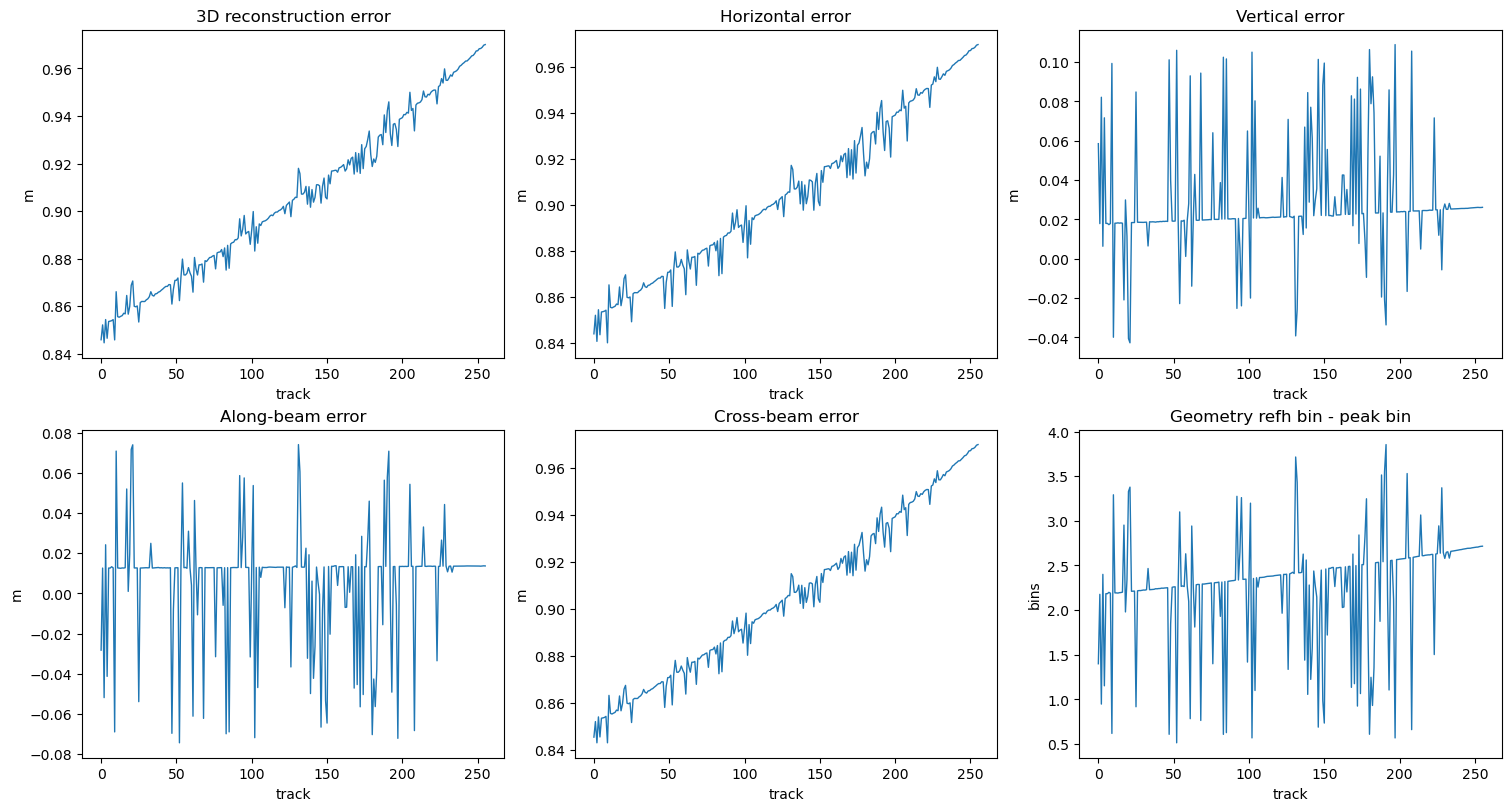

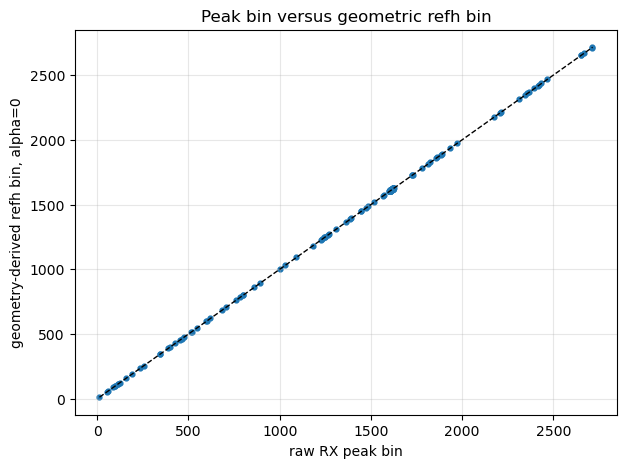

In [11]:
if not best_detail_df.empty:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
    axes[0, 0].plot(best_detail_df['track_num'], best_detail_df['error_3d_m'], lw=1)
    axes[0, 0].set_title('3D reconstruction error')
    axes[0, 0].set_xlabel('track')
    axes[0, 0].set_ylabel('m')

    axes[0, 1].plot(best_detail_df['track_num'], best_detail_df['error_horizontal_m'], lw=1)
    axes[0, 1].set_title('Horizontal error')
    axes[0, 1].set_xlabel('track')
    axes[0, 1].set_ylabel('m')

    axes[0, 2].plot(best_detail_df['track_num'], best_detail_df['error_up_m'], lw=1)
    axes[0, 2].set_title('Vertical error')
    axes[0, 2].set_xlabel('track')
    axes[0, 2].set_ylabel('m')

    axes[1, 0].plot(best_detail_df['track_num'], best_detail_df['error_along_beam_m'], lw=1)
    axes[1, 0].set_title('Along-beam error')
    axes[1, 0].set_xlabel('track')
    axes[1, 0].set_ylabel('m')

    axes[1, 1].plot(best_detail_df['track_num'], best_detail_df['error_cross_beam_m'], lw=1)
    axes[1, 1].set_title('Cross-beam error')
    axes[1, 1].set_xlabel('track')
    axes[1, 1].set_ylabel('m')

    axes[1, 2].plot(best_detail_df['track_num'], best_detail_df['bin_offset_geom_minus_peak'], lw=1)
    axes[1, 2].set_title('Geometry refh bin - peak bin')
    axes[1, 2].set_xlabel('track')
    axes[1, 2].set_ylabel('bins')
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(best_detail_df['rx_peak_bin_raw'], best_detail_df['b_ref_geom_alpha0'], s=12)
    lo = min(best_detail_df['rx_peak_bin_raw'].min(), best_detail_df['b_ref_geom_alpha0'].min())
    hi = max(best_detail_df['rx_peak_bin_raw'].max(), best_detail_df['b_ref_geom_alpha0'].max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    ax.set_xlabel('raw RX peak bin')
    ax.set_ylabel('geometry-derived refh bin, alpha=0')
    ax.set_title('Peak bin versus geometric refh bin')
    ax.grid(True, alpha=0.3)
    plt.show()
else:
    print('No best-detail data available.')

## 10. Waveform heatmap with peak and geometric refh bin

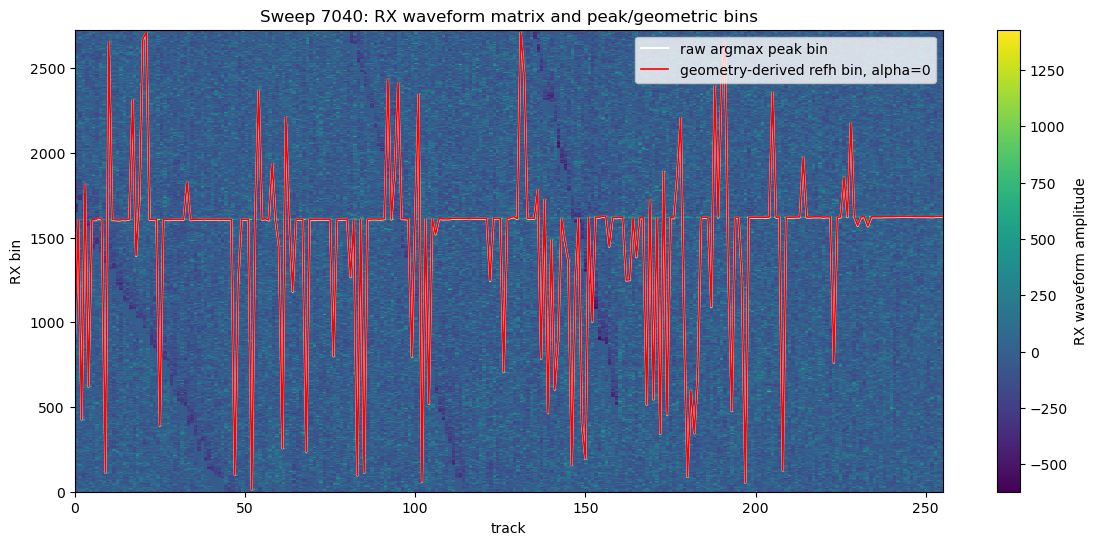

In [12]:
if rx_waveforms.size:
    fig, ax = plt.subplots(figsize=(14, 6))
    im = ax.imshow(
        rx_waveforms.T,
        aspect='auto',
        origin='lower',
        interpolation='nearest',
        extent=[sweep_df['track_num'].min(), sweep_df['track_num'].max(), 0, rx_waveforms.shape[1] - 1],
    )
    ax.plot(sweep_df['track_num'], sweep_df['rx_peak_bin_raw'], color='white', lw=1.5, label='raw argmax peak bin')
    if not best_detail_df.empty:
        ax.plot(best_detail_df['track_num'], best_detail_df['b_ref_geom_alpha0'], color='red', lw=1.2, label='geometry-derived refh bin, alpha=0')
    ax.set_title(f'Sweep {SWEEP_INDEX}: RX waveform matrix and peak/geometric bins')
    ax.set_xlabel('track')
    ax.set_ylabel('RX bin')
    ax.legend()
    plt.colorbar(im, ax=ax, label='RX waveform amplitude')
    plt.show()

## 11. 3D visualization: reconstructed refh versus H5 refh

In [13]:
def make_reconstruction_3d_figure(detail_df: pd.DataFrame, epsg: int, max_lines: int = 256) -> go.Figure:
    if detail_df.empty:
        return go.Figure()
    P = detail_df[['refh_x', 'refh_y', 'refh_z']].to_numpy(dtype=np.float64)
    Phat = detail_df[['x_hat', 'y_hat', 'z_hat']].to_numpy(dtype=np.float64)
    center = np.nanmedian(P, axis=0)
    Pp = P - np.array([center[0], center[1], 0.0])
    Hp = Phat - np.array([center[0], center[1], 0.0])
    fig = go.Figure()
    fig.add_trace(go.Scatter3d(
        x=Pp[:, 0], y=Pp[:, 1], z=Pp[:, 2],
        mode='markers', marker=dict(size=4, color='#1f77b4'), name='H5 refh',
        text=[f"track={int(t)}<br>H5 refh z={z:.3f} m<br>3D err={e:.3f} m" for t, z, e in zip(detail_df['track_num'], detail_df['refh_z'], detail_df['error_3d_m'])],
        hoverinfo='text',
    ))
    fig.add_trace(go.Scatter3d(
        x=Hp[:, 0], y=Hp[:, 1], z=Hp[:, 2],
        mode='markers', marker=dict(size=3, color='#d62728'), name='forward reconstructed refh', hoverinfo='skip',
    ))
    ids = np.arange(len(detail_df))
    if len(ids) > max_lines:
        ids = ids[np.linspace(0, len(ids)-1, max_lines).round().astype(int)]
    xs, ys, zs = [], [], []
    for idx in ids:
        xs += [Hp[idx, 0], Pp[idx, 0], None]
        ys += [Hp[idx, 1], Pp[idx, 1], None]
        zs += [Hp[idx, 2], Pp[idx, 2], None]
    fig.add_trace(go.Scatter3d(
        x=xs, y=ys, z=zs, mode='lines',
        line=dict(color='rgba(244,63,94,0.55)', width=2), name='reconstruction residual', hoverinfo='skip',
    ))
    fig.update_layout(
        title='Forward-reconstructed refh versus H5 refh',
        scene=dict(
            xaxis_title='Easting offset from median refh (m)',
            yaxis_title='Northing offset from median refh (m)',
            zaxis_title='Height (m)',
            aspectmode='data',
        ),
        height=720,
        margin=dict(l=0, r=0, t=40, b=0),
    )
    return fig

if not best_detail_df.empty and EPSG is not None:
    make_reconstruction_3d_figure(best_detail_df, EPSG, max_lines=MAX_RESIDUAL_LINES_3D).show()
else:
    print('No reconstruction detail data available for 3D plot.')

## 12. Inspect one track waveform

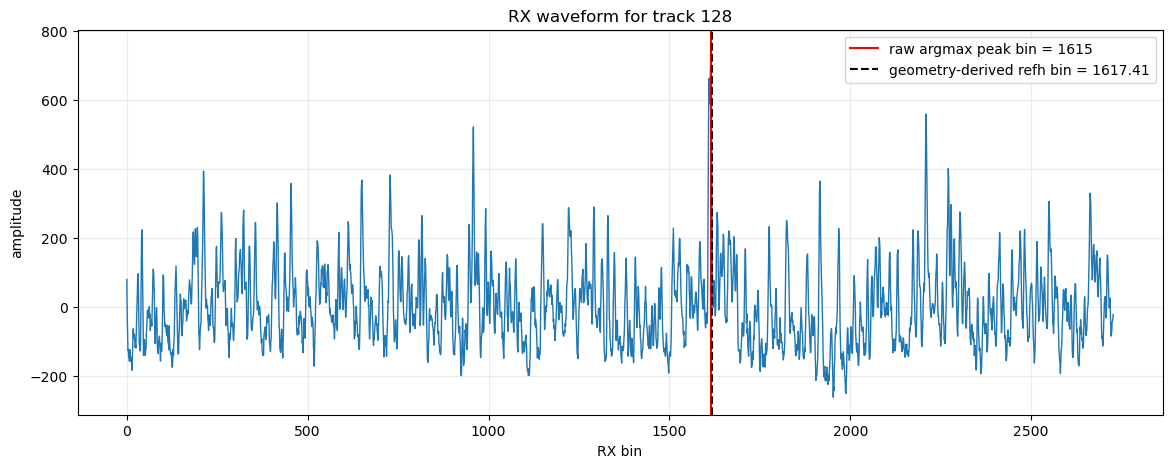

In [14]:
if rx_waveforms.size and not best_detail_df.empty:
    row_match = sweep_df.loc[sweep_df['track_num'] == TRACK_TO_VIEW]
    if row_match.empty:
        print(f'TRACK_TO_VIEW={TRACK_TO_VIEW} not found.')
    else:
        local_idx = int(row_match.index[0])
        rx = rx_waveforms[local_idx, :]
        geom_bin = float(best_detail_df.loc[best_detail_df['track_num'] == TRACK_TO_VIEW, 'b_ref_geom_alpha0'].iloc[0])
        peak_bin = int(sweep_df.loc[sweep_df['track_num'] == TRACK_TO_VIEW, 'rx_peak_bin_raw'].iloc[0])
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(rx, lw=1)
        ax.axvline(peak_bin, color='red', lw=1.5, label=f'raw argmax peak bin = {peak_bin}')
        ax.axvline(geom_bin, color='black', lw=1.5, ls='--', label=f'geometry-derived refh bin = {geom_bin:.2f}')
        ax.set_title(f'RX waveform for track {TRACK_TO_VIEW}')
        ax.set_xlabel('RX bin')
        ax.set_ylabel('amplitude')
        ax.legend()
        ax.grid(True, alpha=0.25)
        plt.show()

## 13. Interpretation guide

Use the model summary table to determine the state of the bin-geolocation model.

### If the best model has meter-level 3D error

Then the following are mutually consistent for this sweep:

- H5 instrument position;
- H5 beam angles;
- H5 `rwstart/rwstop`;
- H5 `bin_size`;
- raw RX waveform peak bin;
- H5 `refh` coordinate.

This strongly supports geolocating other RX bins with the same ray/range model, subject to the confirmed bin-center convention.

### If the best model has large along-beam error but small cross-beam error

The beam direction is likely correct, but the bin/range model is incomplete. Likely causes include sub-bin peak localization, a processed peak definition, a missing range-bias/bounce-time/atmospheric correction, or wrong bin-center/bin-edge convention.

### If the best model has large cross-beam error

The angle-derived ray does not pass close to H5 `refh`. Likely causes include wrong angle convention, missing pointing/bias correction, timing mismatch, or additional geolocation correction not modeled here.

### Conservative final statement

This notebook gives a strict forward test. It should be used to determine whether all-bin geolocation can be promoted from theory to an operational assumption.